In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# дефолтный стиль графиков
sns.set_theme(style="whitegrid")

# читаем файл (мы в папке notebooks, так что делаем шаг назад ../)
df = pd.read_csv('../data/processed/all_supplements_clean.csv')

print(f"всего товаров: {len(df)}")
display(df.head())

всего товаров: 900


,Категория,Бренд,Название,Цена (руб),Рейтинг,Кол-во отзывов
0,креатин,PWR ultimate power,Креатин моногидрат порошок creatine 300 г,614,4.9,76823
1,креатин,DER BAUM IST GOLDEN,Креатин моногидрат порошок,1391,4.9,18115
2,креатин,Prime Kraft,"Креатин моногидрат Creatine Monohydrate, без в...",527,4.9,41922
3,креатин,BIOVIN,"Креатин моногидрат порошок 300г,бад,creatine m...",363,4.9,102238
4,креатин,GreenSanTe,Креатин моногидрат GST 300гр премиум,800,4.8,4870


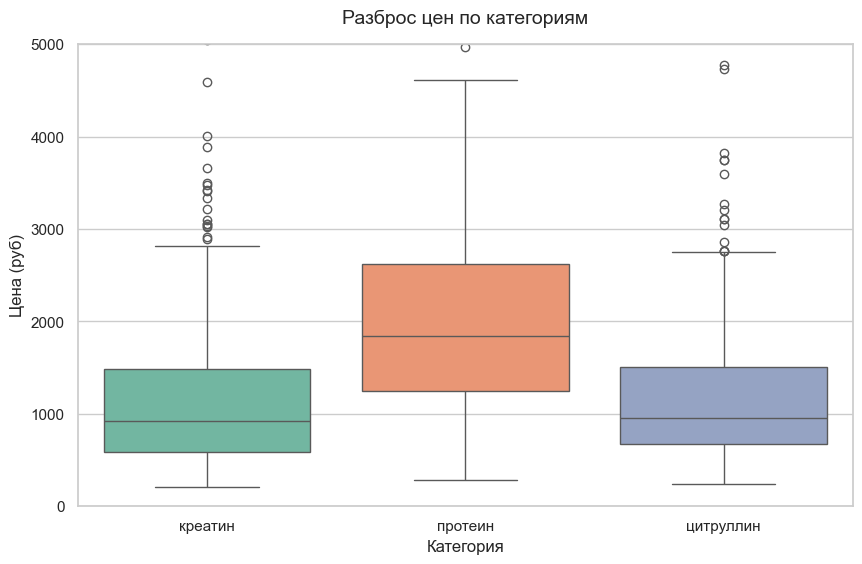

In [7]:
plt.figure(figsize=(10, 6))

# смотрим разброс цен. hue нужен, чтобы seaborn не кидал FutureWarning
sns.boxplot(data=df, x='Категория', y='Цена (руб)', hue='Категория', palette='Set2', legend=False)

plt.title('Разброс цен по категориям', fontsize=14, pad=15)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Цена (руб)', fontsize=12)

# отрезаем выбросы, иначе пару банок за 15к сломают масштаб всего графика
plt.ylim(0, 5000) 

plt.show()

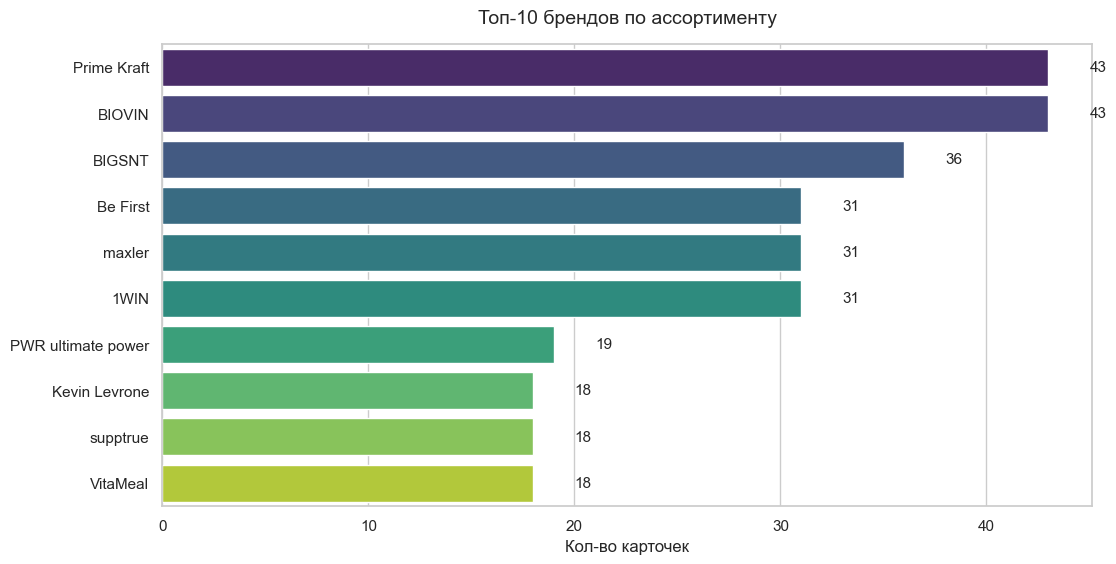

In [8]:
# кто забил выдачу карточками
top_brands = df['Бренд'].value_counts().head(10)

plt.figure(figsize=(12, 6))

sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.index, palette='viridis', legend=False)

plt.title('Топ-10 брендов по ассортименту', fontsize=14, pad=15)
plt.xlabel('Кол-во карточек', fontsize=12)
plt.ylabel('', fontsize=12) # убрал подпись оси, и так понятно что это бренды

# добавляем цифры на график, чтобы было нагляднее
for index, value in enumerate(top_brands.values):
    plt.text(value + 2, index, str(value), va='center', fontsize=11)

plt.show()

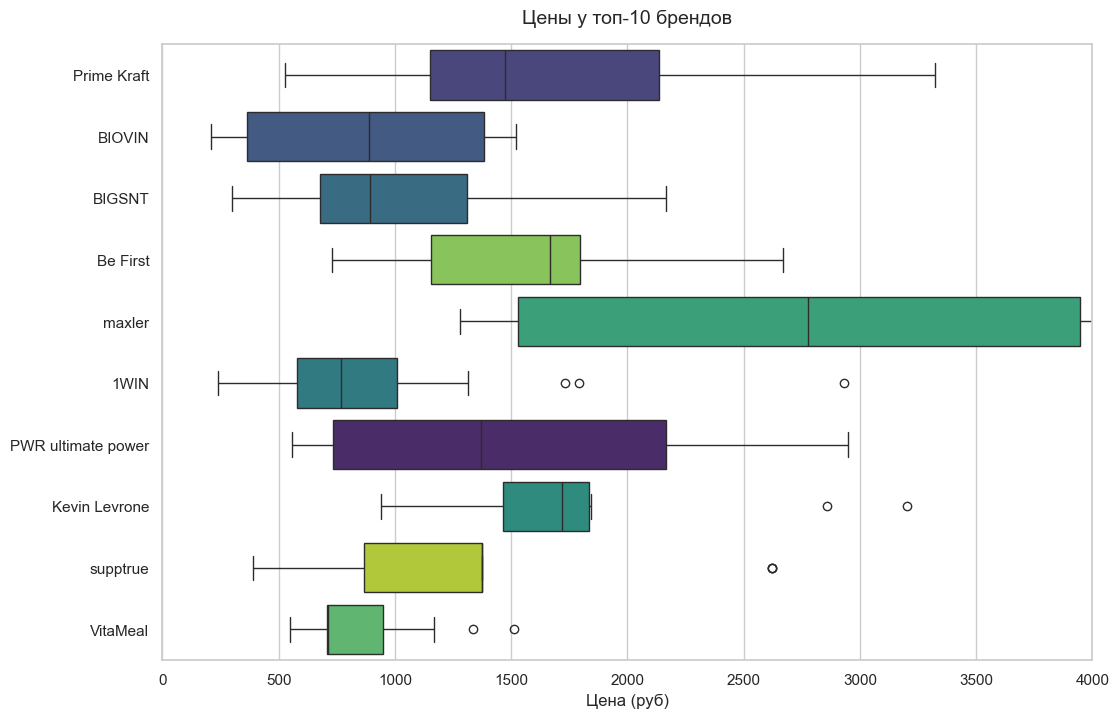

In [9]:
# вытаскиваем названия топов
top_names = top_brands.index.tolist()

# оставляем в датасете только эти 10 брендов
df_top = df[df['Бренд'].isin(top_names)]

plt.figure(figsize=(12, 8))

sns.boxplot(
    data=df_top, 
    y='Бренд', 
    x='Цена (руб)', 
    hue='Бренд', 
    palette='viridis', 
    legend=False, 
    order=top_names # сортируем так же, как на графике выше
)

plt.title('Цены у топ-10 брендов', fontsize=14, pad=15)
plt.xlabel('Цена (руб)', fontsize=12)
plt.ylabel('') 
plt.xlim(0, 4000) # тоже режем хвосты

plt.show()